<a href="https://colab.research.google.com/github/ombarvaliya/Infosys_FakeJob_Detection_using_NLP/blob/main/01_prepare_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
dfA = pd.read_csv("../Dataset/Fake Postings.csv")
dfB = pd.read_csv("../Dataset/fake_job_postings_800fake.csv")

C:\Users\Om\AppData\Local\Temp\ipykernel_58172\402296617.py:2: DtypeWarning: Columns (5,6,13) have mixed types. Specify dtype option on import or set low_memory=False.
  dfB = pd.read_csv("../Dataset/fake_job_postings_800fake.csv")


In [3]:
required_columns = [
    "title", "description", "requirements", "company_profile",
    "employment_type", "industry", "benefits", "salary_range", "fraudulent"
]

dfA = dfA[required_columns]
dfB = dfB[required_columns]

In [4]:
print("Dataset A shape:", dfA.shape)
print("Dataset B shape:", dfB.shape)

Dataset A shape: (10000, 9)
Dataset B shape: (42019, 9)


In [5]:
dfA = dfA.fillna("")
dfB = dfB.fillna("")

In [6]:
df_final = pd.concat([dfA, dfB], ignore_index=True)

In [7]:
print("Before deduplication:")
print(f"  Total rows: {len(df_final)}")
print(f"  Fraudulent: {(df_final['fraudulent'] == 1).sum()}")
print(f"  Real: {(df_final['fraudulent'] == 0).sum()}")

# Remove exact duplicates across all columns
df_final.drop_duplicates(inplace=True)

print("\nAfter removing exact duplicates:")
print(f"  Total rows: {len(df_final)}")
print(f"  Fraudulent: {(df_final['fraudulent'] == 1).sum()}")
print(f"  Real: {(df_final['fraudulent'] == 0).sum()}")

# Remove duplicates based on description (most important field)
df_final.drop_duplicates(subset=['description'], inplace=True)

print("\nAfter removing description duplicates:")
print(f"  Total rows: {len(df_final)}")
print(f"  Fraudulent: {(df_final['fraudulent'] == 1).sum()}")
print(f"  Real: {(df_final['fraudulent'] == 0).sum()}")

Before deduplication:
  Total rows: 52019
  Fraudulent: 34734
  Real: 17285



After removing exact duplicates:
  Total rows: 50208
  Fraudulent: 34492
  Real: 15716

After removing description duplicates:
  Total rows: 26245
  Fraudulent: 12021
  Real: 14224


In [8]:
print("Final merged shape:", df_final.shape)
print("Fraudulent distribution:")
print(df_final['fraudulent'].value_counts())

Final merged shape: (26245, 9)
Fraudulent distribution:
fraudulent
0    14224
1    12021
Name: count, dtype: int64


In [9]:
df_final.to_csv("merged_job_dataset.csv", index=False)
print("Merged dataset saved as merged_job_dataset.csv")

Merged dataset saved as merged_job_dataset.csv


In [10]:
def combine_text(row):
    return " ".join([
        str(row['title']),
        str(row['description']),
        str(row['requirements']),
        str(row['company_profile']),
        str(row['employment_type']),
        str(row['industry']),
        str(row['benefits']),
        str(row['salary_range'])
    ])

df_final['text'] = df_final.apply(combine_text, axis=1)


In [11]:
df_final[['text', 'fraudulent']].head()

,text,fraudulent
0,Mental health nurse Arm drive court sure vote....,1
1,Conference centre manager Government whom its ...,1
2,"Engineer, land I member discuss follow way the...",1
3,Forest/woodland manager House across wait appr...,1
4,"Production designer, theatre/television/film C...",1


In [12]:
print(df_final['fraudulent'].value_counts())

fraudulent
0    14224
1    12021
Name: count, dtype: int64


In [13]:
df_model = df_final[['text', 'fraudulent']]
df_model.to_csv("clean_job_dataset.csv", index=False)

In [14]:
df_model.info()
df_model.describe()
df_model['fraudulent'].value_counts()

<class 'pandas.core.frame.DataFrame'>
Index: 26245 entries, 0 to 30434
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        26245 non-null  object
 1   fraudulent  26245 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 615.1+ KB


fraudulent
0    14224
1    12021
Name: count, dtype: int64

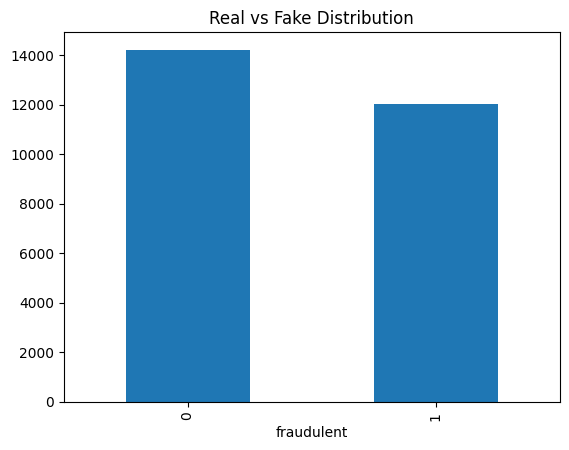

In [15]:
import matplotlib.pyplot as plt
df_model['fraudulent'].value_counts().plot(kind='bar')
plt.title("Real vs Fake Distribution")
plt.show()

In [16]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', ' urltoken ', text)   # replace links
    text = re.sub(r'\S+@\S+', ' emailtoken ', text)                 # replace emails
    text = re.sub(r'\d+', ' numbertoken ', text)                    # replace numbers
    text = re.sub(r'[^\w\s]', ' ', text)                            # remove punctuation only
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df_model['clean_text'] = df_model['text'].apply(clean_text)

C:\Users\Om\AppData\Local\Temp\ipykernel_58172\4248732430.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['clean_text'] = df_model['text'].apply(clean_text)


In [17]:
df_model[['text', 'clean_text', 'fraudulent']].head()

,text,clean_text,fraudulent
0,Mental health nurse Arm drive court sure vote....,mental health nurse arm drive court sure vote ...,1
1,Conference centre manager Government whom its ...,conference centre manager government whom its ...,1
2,"Engineer, land I member discuss follow way the...",engineer land i member discuss follow way ther...,1
3,Forest/woodland manager House across wait appr...,forest woodland manager house across wait appr...,1
4,"Production designer, theatre/television/film C...",production designer theatre television film ca...,1


C:\Users\Om\AppData\Local\Temp\ipykernel_58172\2727525749.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['num_chars'] = df_model['clean_text'].str.len()
C:\Users\Om\AppData\Local\Temp\ipykernel_58172\2727525749.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['num_words'] = df_model['clean_text'].str.split().apply(len)
C:\Users\Om\AppData\Local\Temp\ipykernel_58172\2727525749.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

              num_chars                               num_words         \
                   mean  median          std  count        mean median   
fraudulent                                                               
0           2916.975816  2724.5  1461.618081  14224  438.264904  406.0   
1            446.157641   286.0   609.058361  12021   62.152982   38.0   

                              
                  std  count  
fraudulent                    
0           222.56395  14224  
1            88.54412  12021  
           word  count
0   numbertoken  64083
1      flexible  13447
2         hours  13063
3          earn  12270
4      required  11464
5        hiring  10712
6        degree  10614
7     knowledge  10511
8          week  10279
9         basic  10216
10      contact  10100
11    immediate  10069
12  established  10059
13   emailtoken  10000
14         time   6638
15         work   6323
16         free   4301
17       income   3134
18         home   3045
19   experienc

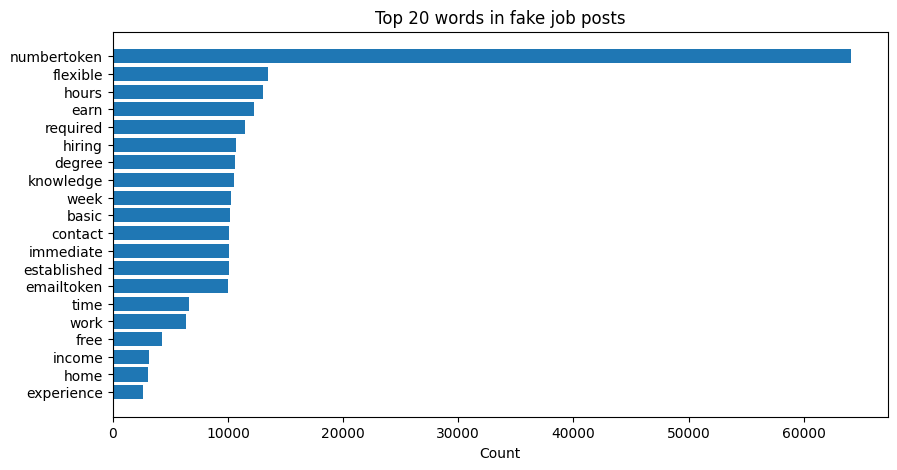

In [18]:
from sklearn.feature_extraction.text import CountVectorizer

# TEXT LENGTH ANALYSIS (fake vs real)
# compute character and word lengths
df_model['num_chars'] = df_model['clean_text'].str.len()
df_model['num_words'] = df_model['clean_text'].str.split().apply(len)

# summary statistics by label (assumes fraudulent==1 means fake)
stats = df_model.groupby('fraudulent')[['num_chars', 'num_words']].agg(['mean','median','std','count'])
print(stats)

# EXTRACT COMMON WORDS IN FAKE POSTS USING VECTORIZATION
fake_texts = df_model.loc[df_model['fraudulent']==1, 'clean_text']

cv = CountVectorizer(stop_words='english', max_features=5000)
X_fake = cv.fit_transform(fake_texts)

# aggregate counts and show top 20
sum_words = X_fake.sum(axis=0).A1
words = cv.get_feature_names_out()
fake_word_counts = pd.DataFrame({'word': words, 'count': sum_words}).sort_values('count', ascending=False).reset_index(drop=True)
print(fake_word_counts.head(20))

# optional: bar plot of top 20 fake words
top20 = fake_word_counts.head(20)
plt.figure(figsize=(10,5))
plt.barh(top20['word'][::-1], top20['count'][::-1])
plt.xlabel('Count')
plt.title('Top 20 words in fake job posts')
plt.show()

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_model['clean_text'],
    df_model['fraudulent'],
    test_size=0.2,
    random_state=42,
    stratify=df_model['fraudulent']
)

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

# OPTIMIZED PARAMETERS FOR FAKE JOB DETECTION
tfidf = TfidfVectorizer(
    max_features=5000,        # Reduced from 500k for speed (captures key scam indicators)
    ngram_range=(1, 2),       # Reduced from (1, 4) to 1-2 grams
    min_df=1,                 # Capture rare scam keywords
    max_df=0.99,              # Allow up to 99% of documents
    sublinear_tf=True,        # Logarithmic scaling
    lowercase=True
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF Vectorizer Configuration:")
print(f"  - Max features: 5,000")
print(f"  - N-gram range: (1, 2)")
print(f"  - Min DF: 1 (capture rare keywords)")
print(f"  - Max DF: 0.99")
print(f"  - Vocabulary size: {len(tfidf.get_feature_names_out()):,}")

TF-IDF Vectorizer Configuration:
  - Max features: 5,000
  - N-gram range: (1, 2)
  - Min DF: 1 (capture rare keywords)
  - Max DF: 0.99
  - Vocabulary size: 5,000


In [21]:
from sklearn.linear_model import LogisticRegression

# OPTIMIZED FOR FAKE JOB DETECTION WITH CLASS WEIGHTING
model = LogisticRegression(
    max_iter=1000,                     # Reduced from 10000 for faster convergence
    class_weight={0: 1, 1: 50},       # 50x penalty for misclassifying fake jobs (CRITICAL!)
    solver='lbfgs',                    # Faster than saga for smaller feature sets
    C=0.01,                            # Very strong regularization
    tol=1e-4,
    random_state=42,
    n_jobs=-1
)

print("Training Logistic Regression with optimized parameters...")
print("  - Class weight: 50x penalty for missing fake jobs")
print("  - C: 0.01 (strong regularization)")
print("  - Solver: lbfgs (faster convergence)")
print("  - Max iterations: 1,000")

model.fit(X_train_tfidf, y_train)
print("Training complete!")

Training Logistic Regression with optimized parameters...
  - Class weight: 50x penalty for missing fake jobs
  - C: 0.01 (strong regularization)
  - Solver: lbfgs (faster convergence)
  - Max iterations: 1,000
Training complete!
Training complete!


In [22]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6121165936368832
              precision    recall  f1-score   support

           0       1.00      0.28      0.44      2845
           1       0.54      1.00      0.70      2404

    accuracy                           0.61      5249
   macro avg       0.77      0.64      0.57      5249
weighted avg       0.79      0.61      0.56      5249

[[ 810 2035]
 [   1 2403]]


In [23]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Train Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Make predictions
y_pred_nb = nb_model.predict(X_test_tfidf)

# Evaluate model
print("Naive Bayes Model Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

Naive Bayes Model Performance
Accuracy: 0.9792341398361593

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      2845
           1       1.00      0.96      0.98      2404

    accuracy                           0.98      5249
   macro avg       0.98      0.98      0.98      5249
weighted avg       0.98      0.98      0.98      5249


Confusion Matrix:
[[2844    1]
 [ 108 2296]]


In [24]:
import joblib
import os

# Save the trained LogisticRegression model
model_filename = 'logistic_regression_model.pkl'
joblib.dump(model, model_filename)
print(f"Model saved as {model_filename}")

# Save the TF-IDF vectorizer
vectorizer_filename = 'tfidf_vectorizer.pkl'
joblib.dump(tfidf, vectorizer_filename)
print(f"Vectorizer saved as {vectorizer_filename}")

print("\nFiles saved successfully!")
print(f"- {model_filename}")
print(f"- {vectorizer_filename}")

Model saved as logistic_regression_model.pkl
Vectorizer saved as tfidf_vectorizer.pkl

Files saved successfully!
- logistic_regression_model.pkl
- tfidf_vectorizer.pkl
Vectorizer saved as tfidf_vectorizer.pkl

Files saved successfully!
- logistic_regression_model.pkl
- tfidf_vectorizer.pkl
